In [2]:
from pathlib import Path
import os

import numpy as np
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedShuffleSplit
from treeple import HonestForestClassifier
from treeple.datasets import (make_trunk_classification,
                              make_trunk_mixture_classification)
from sklearn.metrics import roc_auc_score, roc_curve

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import string
import matplotlib.lines as mlines

In [3]:
sns.set(font_scale=2)

# plt.rcParams['xtick.major.size'] = 20
plt.rcParams["xtick.major.width"] = 3
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True



In [4]:
fig5A = pd.read_csv('/home/ybai31/might/revised_might/fig/fig5A.csv')
fig5B = pd.read_csv('/home/ybai31/might/revised_might/fig/fig5B.csv')
fig5C = pd.read_csv('/home/ybai31/might/revised_might/fig/fig5C.csv')
print(fig5A.head())
print(fig5A.head())

                       Variable Set  Pancreas_S98_one  Breast_S98_one  \
0          LociFraction.AluFraction          0.126984        0.198413   
1         LociFraction.cCREFraction          0.158730        0.063492   
2        LociFraction.LINEsFraction          0.095238        0.015873   
3  LociFraction.CompartmentFraction          0.150794        0.063492   
4      MotifAnalysis.CongruentDimer          0.400000        0.309524   

   Breast_S98_comight_B  Pancreas_S98_comight_P  
0              0.333333                   0.528  
1              0.380952                   0.624  
2              0.333333                   0.504  
3              0.341270                   0.472  
4              0.412698                   0.456  
                       Variable Set  Pancreas_S98_one  Breast_S98_one  \
0          LociFraction.AluFraction          0.126984        0.198413   
1         LociFraction.cCREFraction          0.158730        0.063492   
2        LociFraction.LINEsFraction       

In [5]:
fontsize = 45
palette = palette = {
    'might': 'red',
    'rf':    'blue',
    'svm':   'green',
    'nb':    'purple',
    'lr':    'orange'
}


0

0.37
0.5
0.61



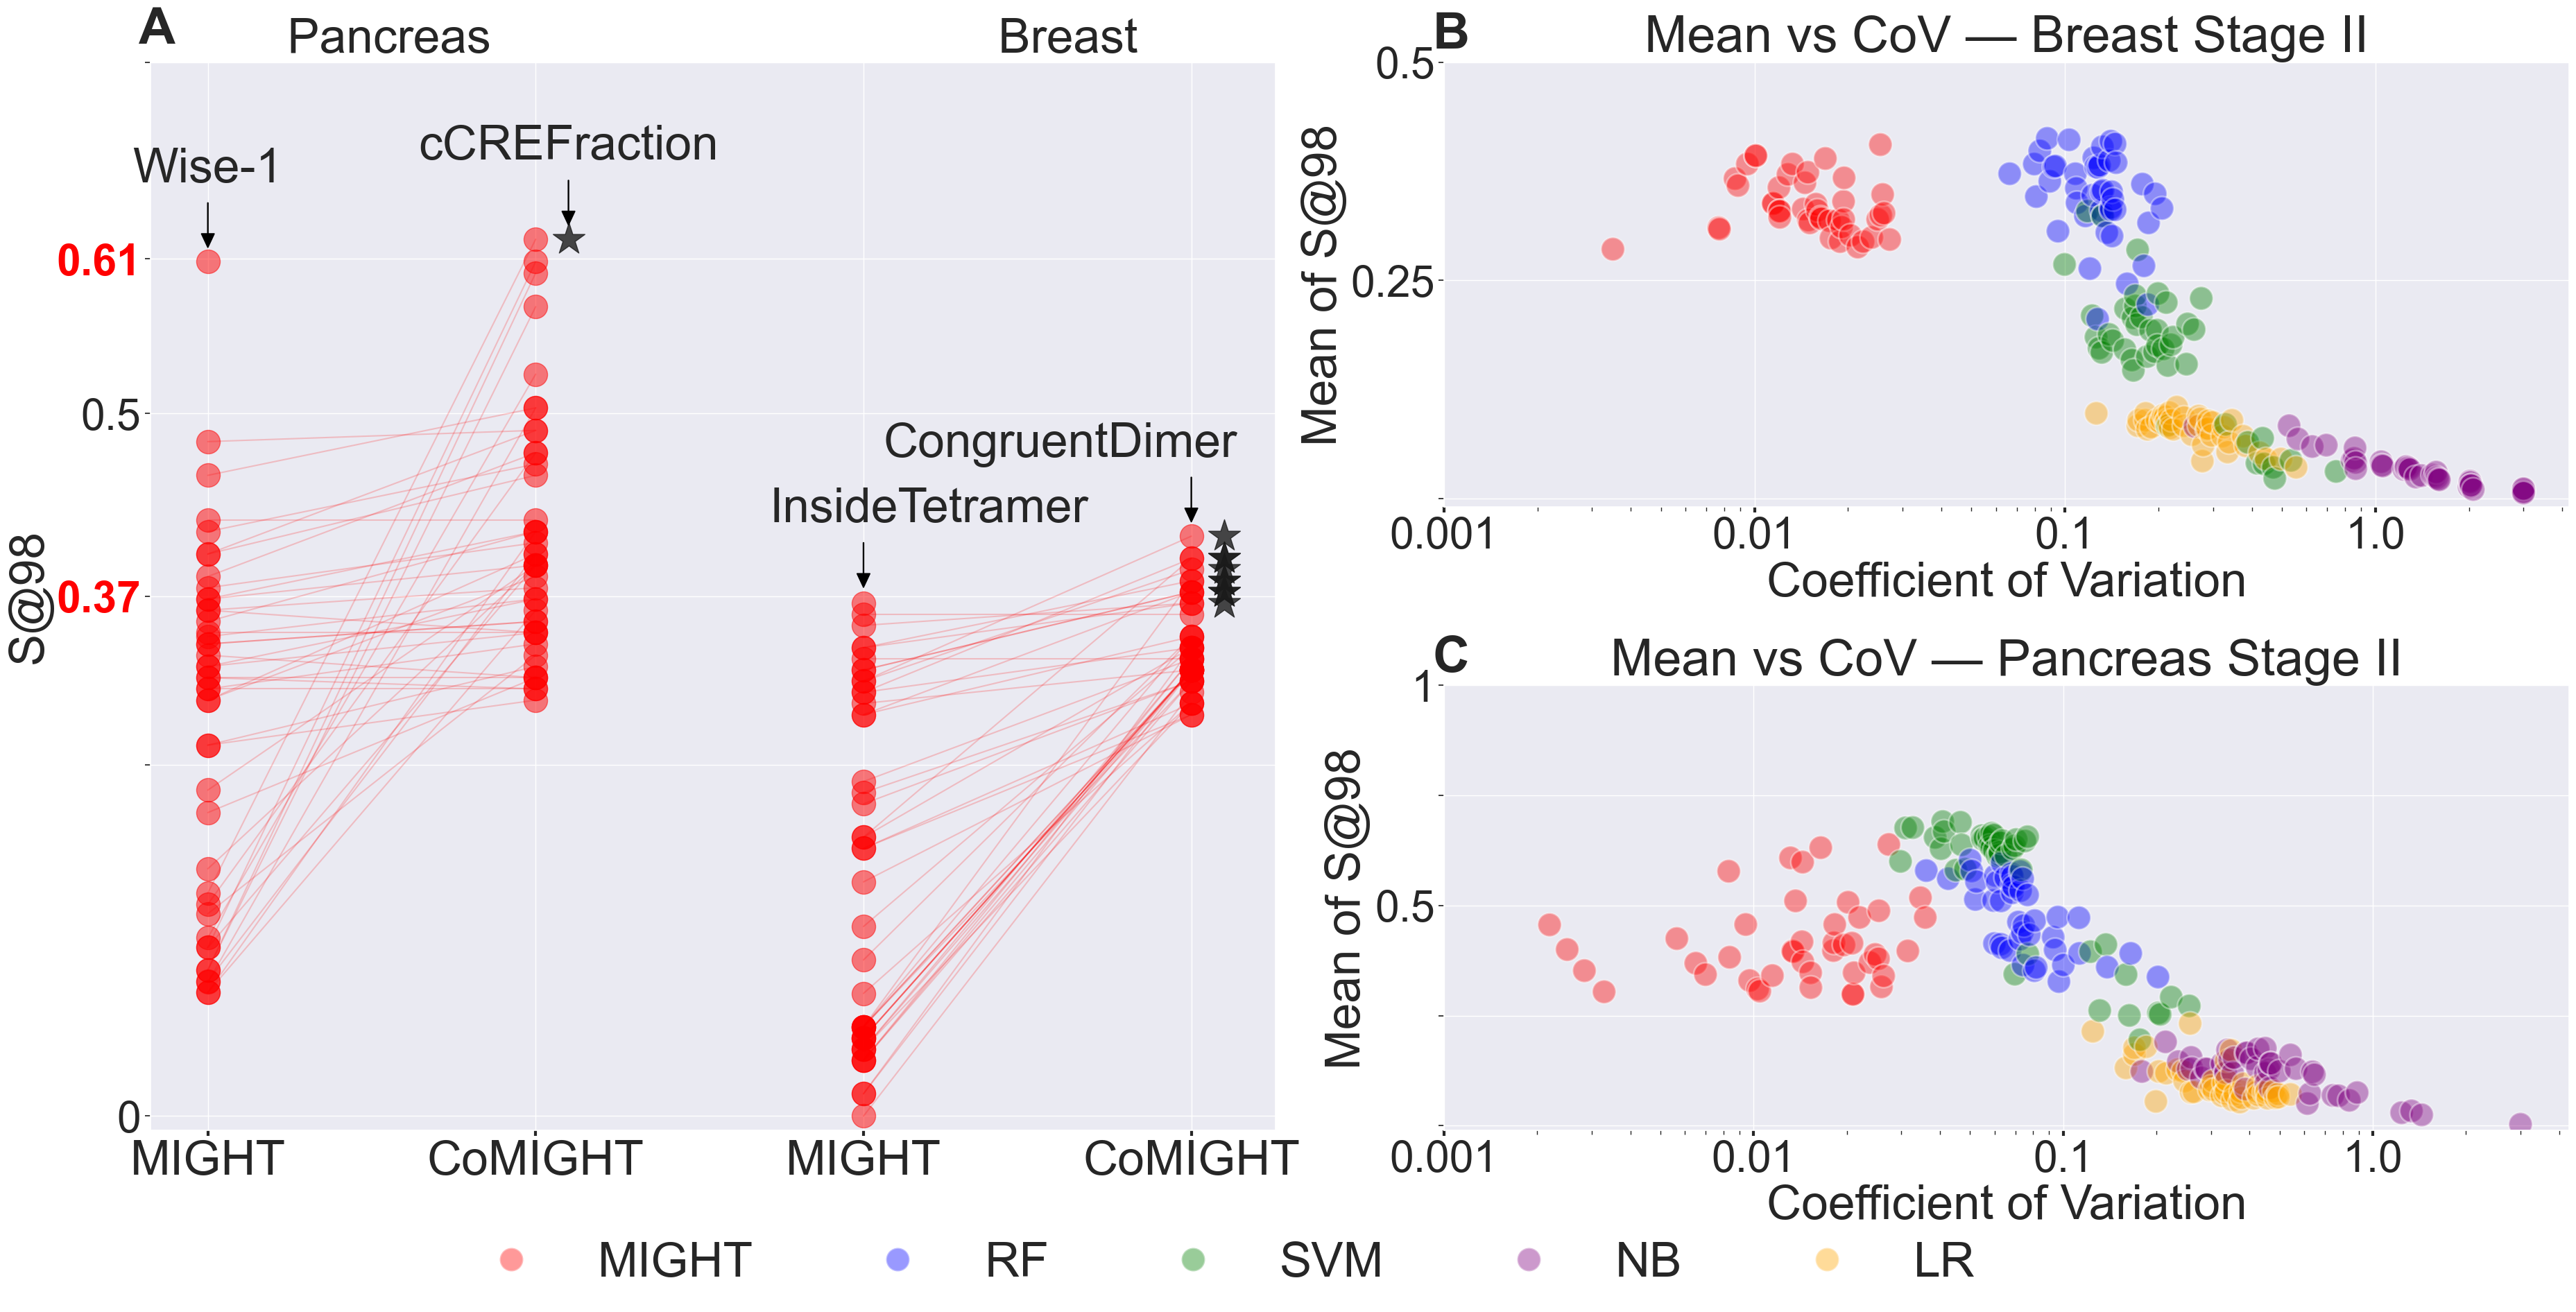

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 2:1 width:height makes left subplot (which is half the width and full height) square
fig = plt.figure(figsize=(45, 20))
gs  = gridspec.GridSpec(2, 2,
                        width_ratios =[1, 1],
                        height_ratios=[1, 1],
                        hspace=0.4, wspace=0.15,
                        figure=fig)

# Left subplot spans both rows
ax1 = fig.add_subplot(gs[:, 0])

# Top‐right and bottom‐right
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])


for ax, letter in zip([ax1, ax2, ax3], ["A", "B", "C"]):
    ax.text(-0.01, 1.008, letter,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=fontsize+8, fontweight="bold")

# --- First (square) plot on ax1 ---
for i, row in fig5A.iterrows():
    # Pancreas in red
    if i == 1:
        ax1.scatter(0.25, row["Pancreas_S98_one"],        color="red",   s=600, alpha=0.5)
        ax1.scatter(0.75, row["Pancreas_S98_comight_P"],        color="red",   s=600, alpha=0.5)
        ax1.scatter(0.80, row["Pancreas_S98_comight_P"],  color="k",   s=1200, alpha=0.8,marker="*",edgecolors="k")
        x_mid = 0.90
        y_mid = (row["Pancreas_S98_comight_P"] + row["Pancreas_S98_comight_P"])/2 + 0.03
        ax1.annotate(row["Variable Set"].split('.')[-1],
                     (x_mid-0.1, y_mid+0.02),
                     textcoords="offset points", xytext=(0,10), ha='center',
                     fontsize=fontsize+5)
        ax1.arrow(x_mid-0.1, y_mid+0.012, 0, -0.032,
                  head_width=0.02, head_length=0.01,
                  length_includes_head=True,color='black' )
    elif i != 23:
        ax1.scatter(0.25, row["Pancreas_S98_one"],        color="red",   s=600, alpha=0.5)
        ax1.scatter(0.75, row["Pancreas_S98_comight_P"],  color="red",   s=600, alpha=0.5)
    else:
        ax1.scatter(0.25, row["Pancreas_S98_one"],        color="red",   s=600, alpha=0.5)
    if i == 23:
        x_mid = 0.35
        y_mid = (row["Pancreas_S98_one"] + row["Pancreas_S98_one"])/2 + 0.03
        ax1.annotate(row["Variable Set"].split('.')[-1],
                     (x_mid-0.1, y_mid+0.02),
                     textcoords="offset points", xytext=(0,10), ha='center',
                     fontsize=fontsize+5)
        ax1.arrow(x_mid-0.1, y_mid+0.012, 0, -0.032,
                  head_width=0.02, head_length=0.01,
                  length_includes_head=True,color='black' )
    else:
        ax1.plot([0.25, 0.75],
                 [row["Pancreas_S98_one"], row["Pancreas_S98_comight_P"]],
                 color="red", alpha=0.2)

    # Breast in blue
    if i in [1,4,5,6,9,12,17,19,20]:
        ax1.scatter(1.25, row["Breast_S98_one"],        color="red",   s=600, alpha=0.5)
        ax1.scatter(1.75, row["Breast_S98_comight_B"],        color="red",   s=600, alpha=0.5)
        ax1.scatter(1.80, row["Breast_S98_comight_B"],  color="k",   s=1200, alpha=0.8,marker="*",edgecolors="k")
        if i ==4:
            x_mid = 1.90
            y_mid = (row["Breast_S98_comight_B"] + row["Breast_S98_comight_B"])/2 + 0.03
            ax1.annotate(row["Variable Set"].split('.')[-1],
                        (x_mid-0.3, y_mid+0.02),
                        textcoords="offset points", xytext=(0,10), ha='center',
                        fontsize=fontsize+5)
            ax1.arrow(x_mid-0.1, y_mid+0.012, 0, -0.032,
                    head_width=0.02, head_length=0.01,
                    length_includes_head=True,color='black' )
    elif i != 13:
        ax1.scatter(1.25, row["Breast_S98_one"],        color="red",   s=600, alpha=0.5)
        ax1.scatter(1.75, row["Breast_S98_comight_B"],  color="red",   s=600, alpha=0.5)
    else:
        ax1.scatter(1.25, row["Breast_S98_one"],        color="red",   s=600, alpha=0.5)
    if i == 13:
        x_mid = 1.35
        y_mid = (row["Breast_S98_one"] + row["Breast_S98_comight_B"])/2 + 0.035
        ax1.annotate(row["Variable Set"].split('.')[-1],
                     (x_mid, y_mid+0.02),
                     textcoords="offset points", xytext=(0,10), ha='center',
                     fontsize=fontsize+5)
        ax1.arrow(x_mid-0.1, y_mid+0.012, 0, -0.032,
                  head_width=0.02, head_length=0.01,
                  length_includes_head=True,color='black' )
    else:
        ax1.plot([1.25, 1.75],
                 [row["Breast_S98_one"], row["Breast_S98_comight_B"]],
                 color="red", alpha=0.2)

ax1.set_xticks([0.25,0.75, 1.25,1.75])
ax1.set_ylim([-0.01,0.75])
ax1.set_yticks([0,0.25,0.37,0.5,0.61,0.75])
ax1.set_yticklabels([0,"","0.37","0.5","0.61",""], fontsize=fontsize)
for tick in ax1.get_yticklabels():
    print(tick.get_text())
    if tick.get_text() == "0.37" or tick.get_text() == "0.61":
        tick.set_color("red")
        tick.set_fontweight("bold")

ax1.set_xticklabels(["MIGHT","CoMIGHT","MIGHT","CoMIGHT"],fontsize = fontsize +5)
ax1.set_title(" Pancreas                                      Breast ",fontsize = fontsize+5)
ax1.set_ylabel("S@98",fontsize = fontsize +5)


sns.scatterplot(
    x="CoV",
    y="mean",
    hue="Classifier",
    data=fig5B,
    s=600,
    alpha=0.4,
    ax=ax2,
    palette=palette,
    legend=False
)

# y‐axis ticks & labels
ax2.set_ylim(-0.01, 0.5)
ax2.set_yticks([0,0.25,0.5])
ax2.set_yticklabels(["","0.25", "0.5"], fontsize=fontsize)

# log‐scale x
ax2.set_xscale('log')
ticks = [0.001, 0.01, 0.1, 1.0]
ax2.set_xticks(ticks)
ax2.set_xticklabels([str(t) for t in ticks], fontsize=fontsize)

# labels & title
ax2.set_xlabel('Coefficient of Variation', fontsize=fontsize+5)
ax2.set_ylabel('Mean of S@98',          fontsize=fontsize+5)
ax2.set_title('Mean vs CoV — Breast Stage II', fontsize=fontsize+8)

# --- Example: third plot on ax3 (replace with your own code) ---
sns.scatterplot(
    x="CoV",
    y="mean",
    hue="Classifier",
    data=fig5C,
    s=600,
    alpha=0.4,
    ax=ax3,
    palette=palette
)

# y‐axis ticks & labels
ax3.set_ylim(-0.01, 1.0)
ax3.set_yticks([0,0.25,0.5,0.75,1])
ax3.set_yticklabels(["","", "0.5", "", "1"], fontsize=fontsize)

# log‐scale x
ax3.set_xscale('log')
ticks = [0.001, 0.01, 0.1, 1.0]
ax3.set_xticks(ticks)
ax3.set_xticklabels([str(t) for t in ticks], fontsize=fontsize)

# labels & title
ax3.set_xlabel('Coefficient of Variation', fontsize=fontsize+5)
ax3.set_ylabel('Mean of S@98',          fontsize=fontsize+5)
ax3.set_title('Mean vs CoV — Pancreas Stage II', fontsize=fontsize+8)

# custom legend order & labels
legend_labels = {'rf':'RF','svm':'SVM','might':'MIGHT','nb':'NB','lr':'LR'}
desired_order  = ['might','rf','svm','nb','lr']
handles, labels = ax3.get_legend_handles_labels()
legend_dict    = dict(zip(labels, handles))
reordered      = [legend_dict[l] for l in desired_order if l in legend_dict]
new_labels     = [legend_labels[l]   for l in desired_order]
ax3.legend(reordered, new_labels,
           loc="center", bbox_to_anchor=(-0.2, -0.3),
           ncol=len(new_labels), frameon=False,
           fontsize=fontsize+5)
plt.show()
